In [1]:
from CellInchi import InChI_new
import pickle
from typing import *
import networkx as nx
import matplotlib.pyplot as plt
from utils import *

In [2]:
# 读取测试用例
with open('results/combined_graph.pkl', 'rb') as f:
    G = pickle.load(f)
# 转为无向图
G = G["graph"].to_undirected()
# node type属性转为cell_type
for node in G.nodes():
    G.nodes[node]['cell_type'] = G.nodes[node]['type']
    # 移除type属性
    del G.nodes[node]['type']


In [3]:
# 查看图G的属性
print(G.nodes(data=True))
print(G.edges(data=True))


[(0, {'pos': (2689.6666666666665, 768.5438596491227), 'cell_type': 'MuSC'}), (1, {'pos': (4258.160241367751, 1285.361604648564), 'cell_type': 'Myf'}), (2, {'pos': (4321.030952380952, 1286.2201388888889), 'cell_type': 'Myf'}), (3, {'pos': (4556.706959706959, 1294.5350274725274), 'cell_type': 'Myf'}), (4, {'pos': (3165.135696821516, 1275.80032599837), 'cell_type': 'Myf'}), (5, {'pos': (4068.0546290971824, 1281.737780333525), 'cell_type': 'Myf'}), (6, {'pos': (3050.0443568020255, 1260.6393027558672), 'cell_type': 'Myf'}), (7, {'pos': (4535.239191382618, 1255.4482809502729), 'cell_type': 'Myb'}), (8, {'pos': (4106.1438061742865, 1261.4224306369674), 'cell_type': 'Myf'}), (9, {'pos': (3654.4236361952394, 1248.5737704918033), 'cell_type': 'Myf'}), (10, {'pos': (4379.9655950366605, 1254.1432600112803), 'cell_type': 'Myf'}), (11, {'pos': (3210.3032873807, 1253.0176740897844), 'cell_type': 'Myf'}), (12, {'pos': (3297.1613475177305, 1254.037234042553), 'cell_type': 'Myf'}), (13, {'pos': (3496.27

In [4]:
def visualize_combined_graph(G, node_colors, title="Combined Graph (MuSC, Myoblasts, Myofibers)"):
    """可视化合并后的图"""
    
    plt.figure(figsize=(15, 10))
    
    # 获取节点位置，如果没有则使用spring布局
    pos = nx.get_node_attributes(G, 'pos')
    if not pos:
        pos = nx.spring_layout(G, k=1, iterations=50)
    
    # 定义边的颜色映射规则
    edge_colors = []
    edge_widths = []
    
    for edge in G.edges():
        node1, node2 = edge
        node1_type = G.nodes[node1].get('type', 'unknown')
        node2_type = G.nodes[node2].get('type', 'unknown')
        
        # 根据连接的节点类型确定边的颜色
        if node1_type == 'MuSC' and node2_type == 'MuSC':
            edge_colors.append('red')  # MuSC-MuSC 为红色
            edge_widths.append(3)
        elif (node1_type == 'MuSC' and node2_type == 'Myb') or (node1_type == 'Myb' and node2_type == 'MuSC'):
            edge_colors.append('orange')  # MuSC-Myoblast 为橙色
            edge_widths.append(2.5)
        elif (node1_type == 'MuSC' and node2_type == 'Myf') or (node1_type == 'Myf' and node2_type == 'MuSC'):
            edge_colors.append('purple')  # MuSC-Myofiber 为紫色
            edge_widths.append(2.5)
        elif node1_type == 'Myb' and node2_type == 'Myb':
            edge_colors.append('blue')  # Myoblast-Myoblast 为蓝色
            edge_widths.append(3)
        elif (node1_type == 'Myb' and node2_type == 'Myf') or (node1_type == 'Myf' and node2_type == 'Myb'):
            edge_colors.append('yellow')  # Myoblast-Myofiber 为黄色
            edge_widths.append(3)
        elif node1_type == 'Myf' and node2_type == 'Myf':
            edge_colors.append('green')  # Myofiber-Myofiber 为绿色
            edge_widths.append(3)
        else:
            edge_colors.append('gray')  # 其他类型为灰色
            edge_widths.append(3)
    
    # 获取节点标签（如果有的话）
    labels = {}
    for node in G.nodes():
        if 'label' in G.nodes[node]:
            labels[node] = G.nodes[node]['label']
        elif 'id' in G.nodes[node]:
            labels[node] = str(G.nodes[node]['id'])
        else:
            labels[node] = str(node)
    
    # 绘制图
    nx.draw(G, pos,
            node_color=[node_colors[node] for node in G.nodes()],
            edge_color=edge_colors,
            width=edge_widths,
            node_size=300,
            font_size=8,
            font_color='white',)  # 设置为True以显示标签
    # 显示坐标轴和范围，网格
    plt.axis('on')
    

    
    # 添加图例
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=15, label='MuSC'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=15, label='Myoblast'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=15, label='Myofiber')
    ]
    
    plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1))
    
    plt.axis('equal')  # 确保图形的纵横比为1:1
    plt.tight_layout()
    plt.show()


C:\Users\xiaoxu\AppData\Local\Temp\ipykernel_96516\780760003.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


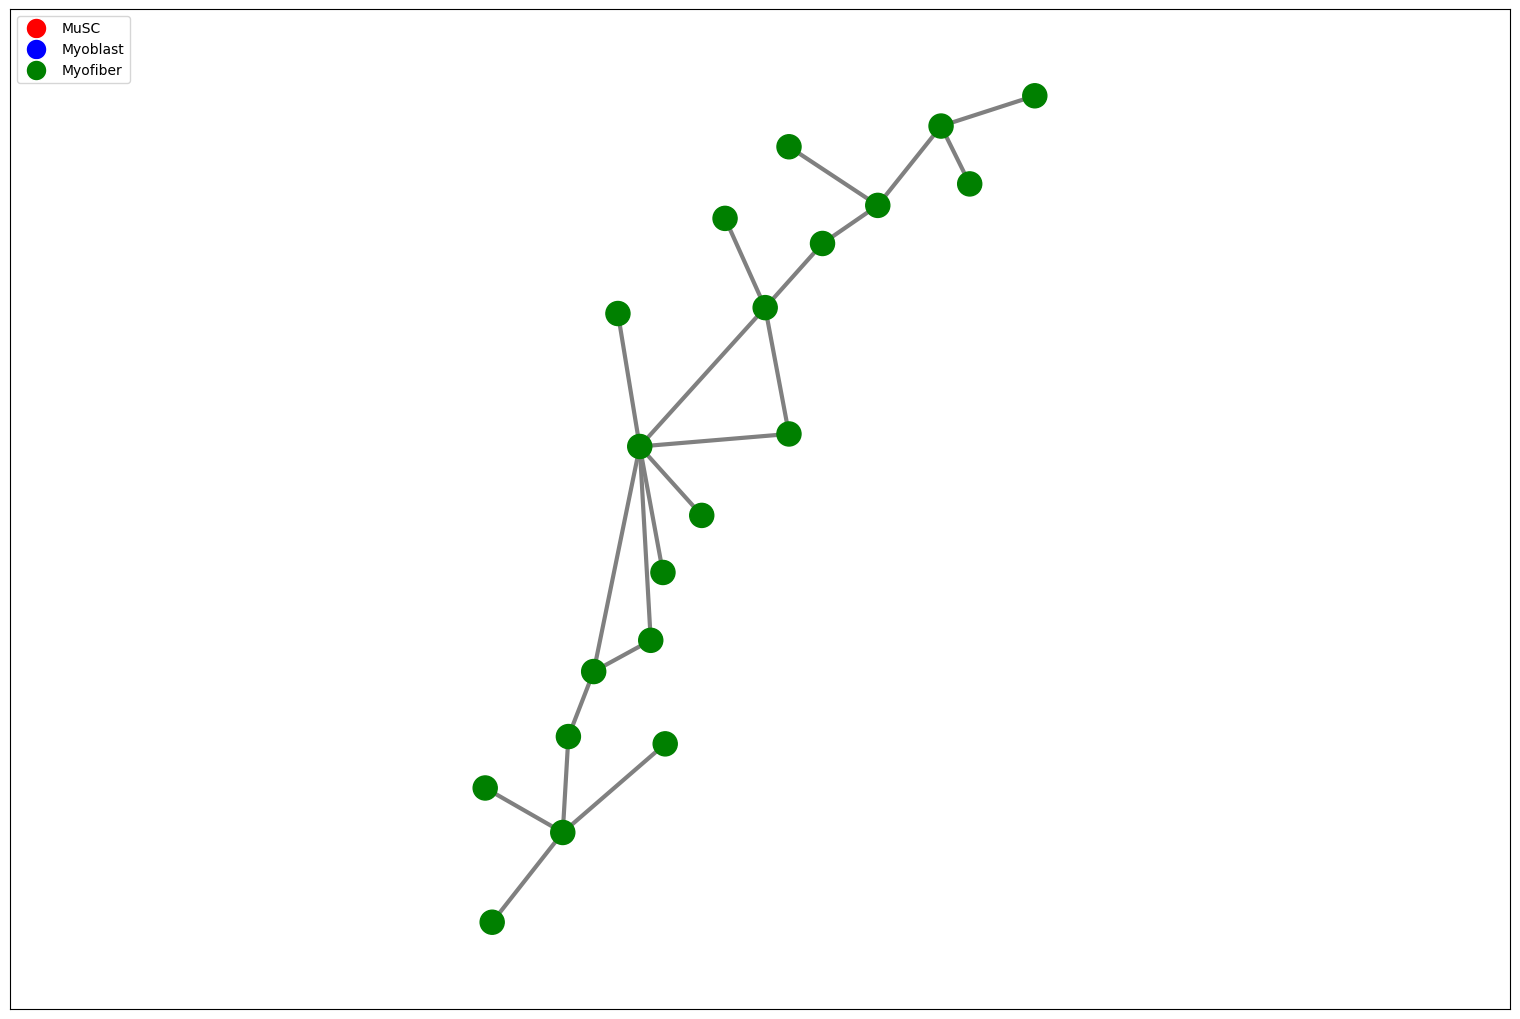

In [5]:

def find_largest_connected_component(G: nx.Graph):
    """找到nx graph中的最大连通分量"""
    # 找到最大连通分量
    largest_component = max(nx.connected_components(G), key=len)
    # 创建最大连通分量的子图
    G_largest = G.subgraph(largest_component).copy()
    return G_largest
# 找到最大连通分量
largest_component = find_largest_connected_component(G)

# 为最大连通分量的节点分配颜色
node_colors = {node: 'red' if G.nodes[node].get('type') == 'MuSC' else
               'blue' if G.nodes[node].get('type') == 'Myb' else
               'green' for node in largest_component.nodes()}

# 可视化最大连通分量
visualize_combined_graph(largest_component, node_colors, title="Largest Connected Component")

In [ ]:
# 可视化largest_component


In [6]:
a = InChI_new(largest_component)
cellinchi = a.to_cellinchi()
print(cellinchi)
# 下一步，

-----start canonical order--------
-----end canonical order--------
CellInChI=1S/Myf20/c1-15-2-16-3-11-19-7-14-20-8-9-10-13-17-12-18-4-5-6/i1-15,2-15,3-16,4-18,5-18,6-18,7-19,8-20,9-20,10-20,11-16,11-19,12-17,12-18,13-17,13-20,14-19,14-20,15-16,17-20,19-20
